In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'Online Retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


# Clean the Data

In [3]:
df.shape

(541909, 8)

In [4]:
df.duplicated().sum()

5268

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.duplicated().sum()

0

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  535187 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.8+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [9]:
# Remove nulls values
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [11]:
# Remove cancelled orders (InvoiceNo starting with 'C')
df=df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [12]:
# Remove negative or zero quantity and unit price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [13]:
# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [14]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

In [15]:
# Add Month and Year columns 
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year
df['Weekday'] = df['InvoiceDate'].dt.day_name()

In [16]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,Year,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2010,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2010,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12,2011,Friday
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12,2011,Friday
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,2011,Friday
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,2011,Friday


In [27]:
df.to_csv('Cleaned_online_relatil.csv', index=False)

# Visualizations

### Top 10 Products by Total Revenue

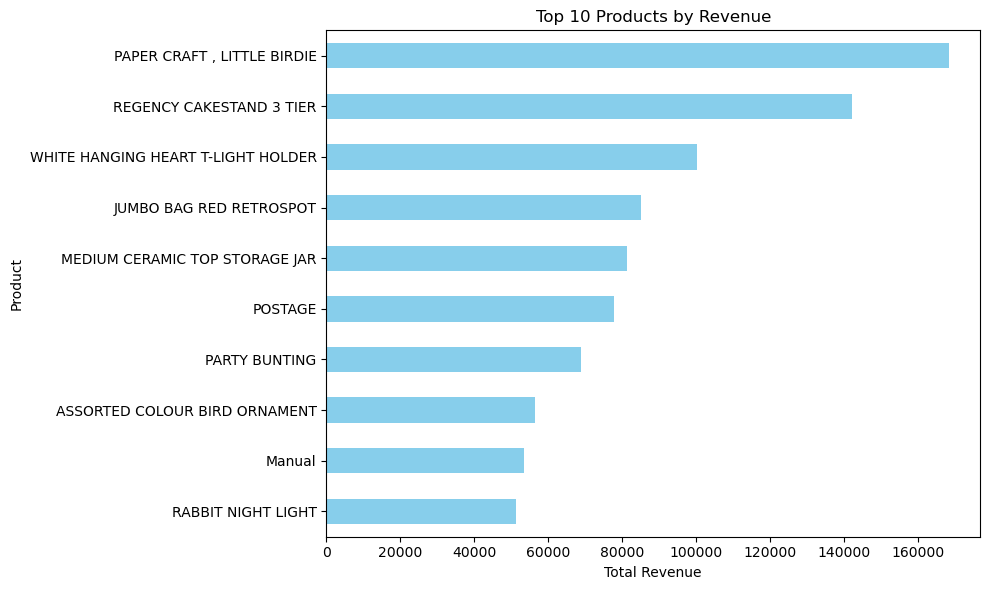

In [17]:
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh', figsize=(10,6), color='skyblue')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Monthly Sales Trend (Seasonality Analysis)

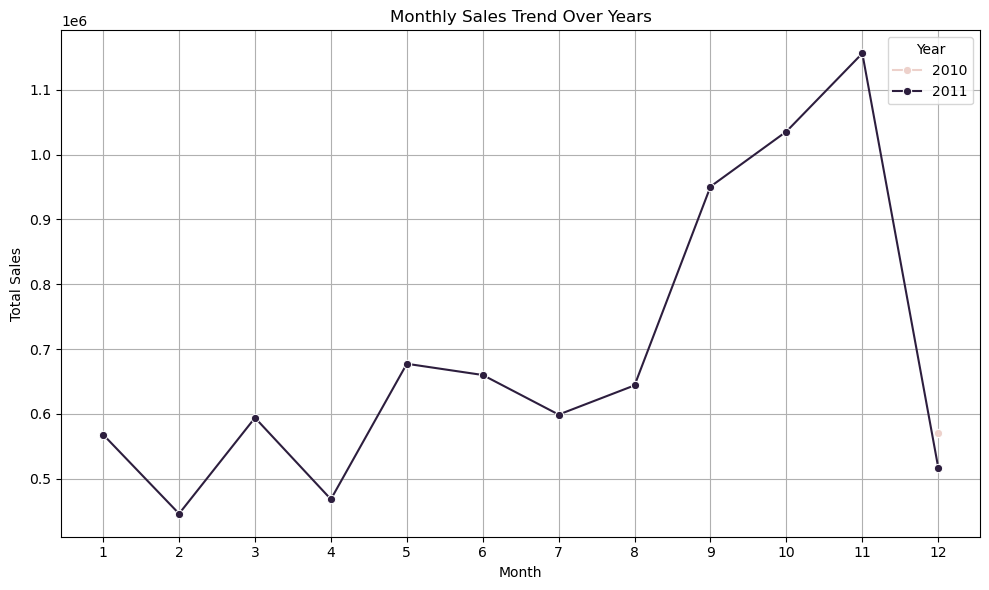

In [18]:
monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_sales, x='Month', y='TotalPrice', hue='Year', marker='o')
plt.title("Monthly Sales Trend Over Years")
plt.ylabel("Total Sales")
plt.xlabel("Month")
plt.xticks(range(1,13))
plt.grid(True)
plt.tight_layout()
plt.show()


### Sales Distribution by Country (Top 10)

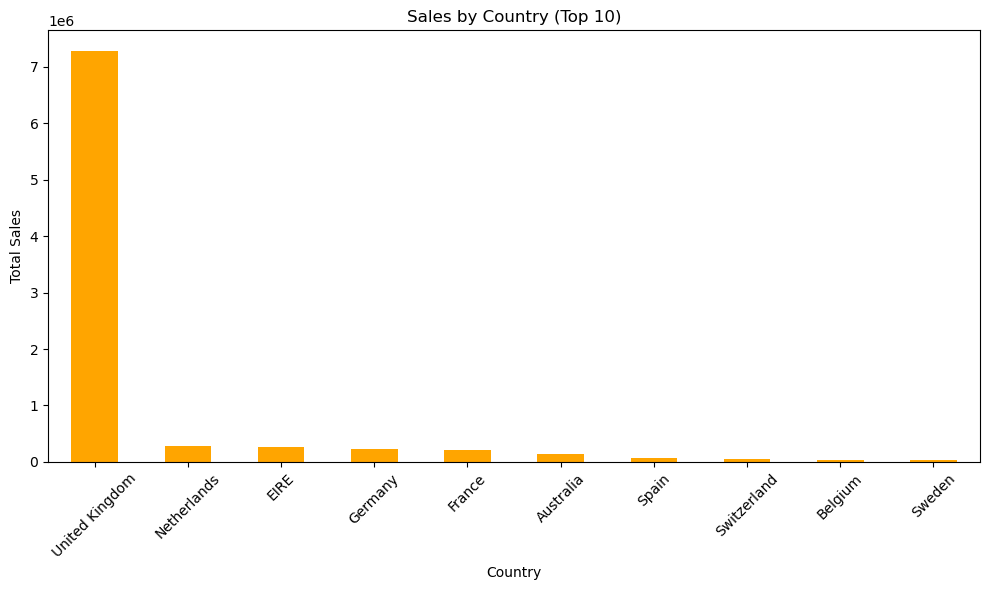

In [19]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar', figsize=(10,6), color='orange')
plt.title('Sales by Country (Top 10)')
plt.ylabel('Total Sales')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Average Unit Price by Product (Top 10)

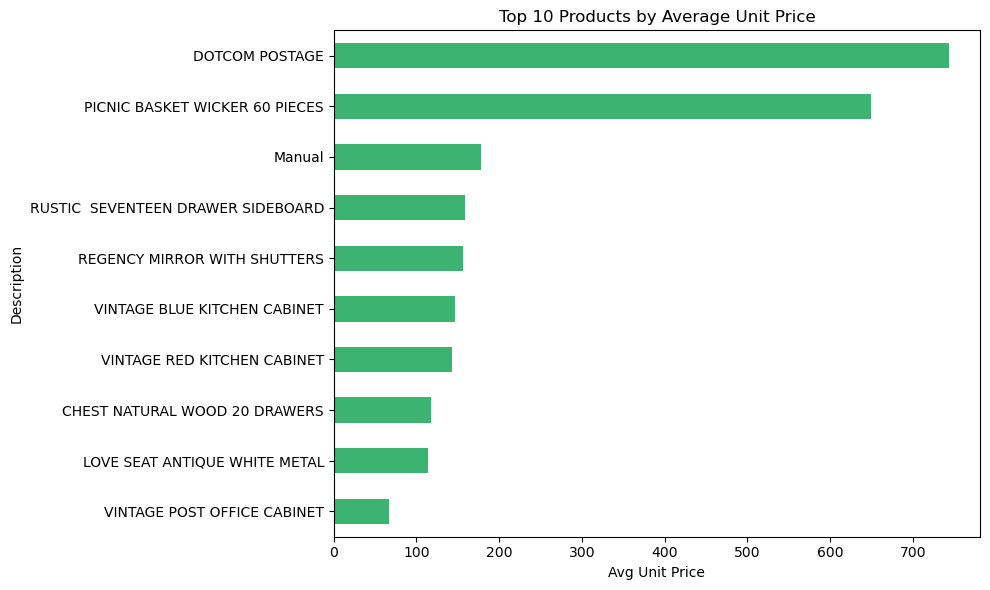

In [20]:
avg_price = df.groupby('Description')['UnitPrice'].mean().sort_values(ascending=False).head(10)

avg_price.plot(kind='barh', figsize=(10,6), color='mediumseagreen')
plt.title('Top 10 Products by Average Unit Price')
plt.xlabel('Avg Unit Price')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Sales by Day of the Week

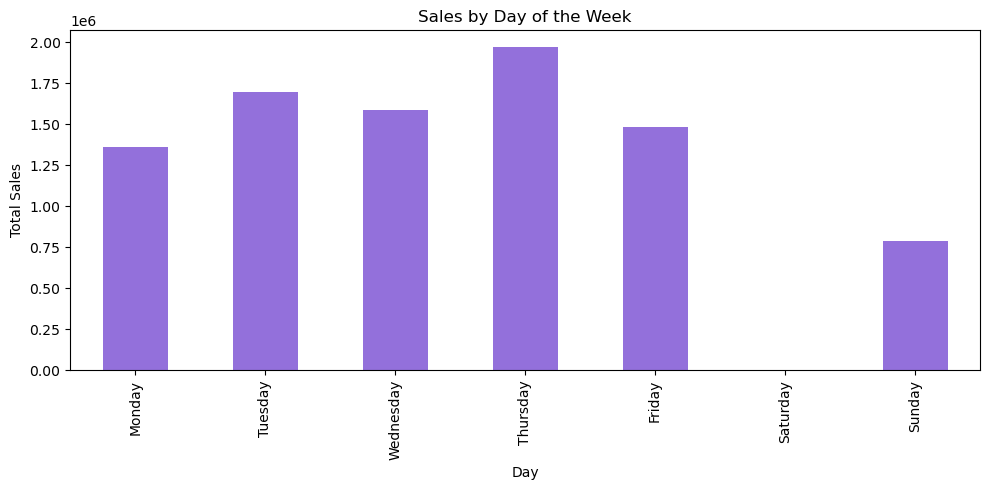

In [21]:
weekday_sales = df.groupby('Weekday')['TotalPrice'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

weekday_sales.plot(kind='bar', figsize=(10,5), color='mediumpurple')
plt.title('Sales by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()


###  Top 10 fast-moving products (by quantity sold)

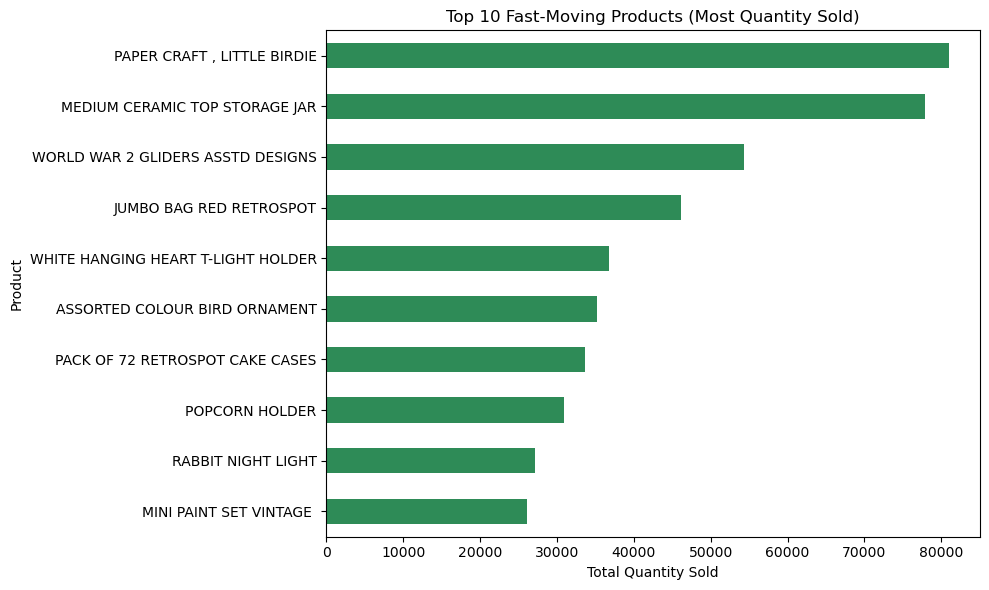

In [22]:
# Top 10 fast-moving products (by quantity sold)
fast_moving = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Plot
fast_moving.plot(kind='barh', figsize=(10,6), color='seagreen')
plt.title('Top 10 Fast-Moving Products (Most Quantity Sold)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Analyze Correlations

### Correlation Heatmap:

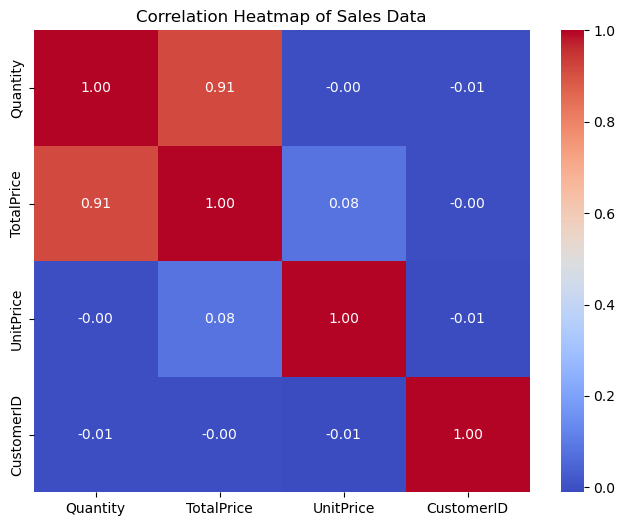

In [23]:
# Calculate the correlation matrix for relevant columns
corr_matrix = df[['Quantity', 'TotalPrice', 'UnitPrice', 'CustomerID']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Sales Data')
plt.show()


### Quantity vs TotalPrice

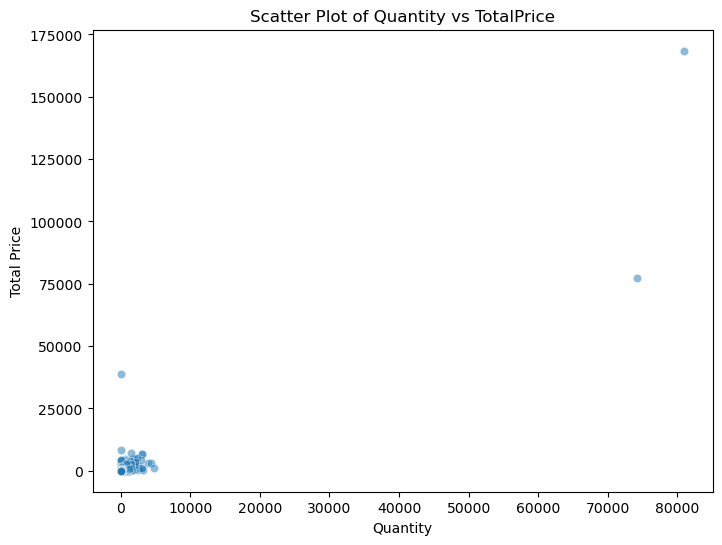

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Quantity', y='TotalPrice', alpha=0.5)
plt.title('Scatter Plot of Quantity vs TotalPrice')
plt.xlabel('Quantity')
plt.ylabel('Total Price')
plt.show()


In [25]:
### Quantity vs UnitPrice

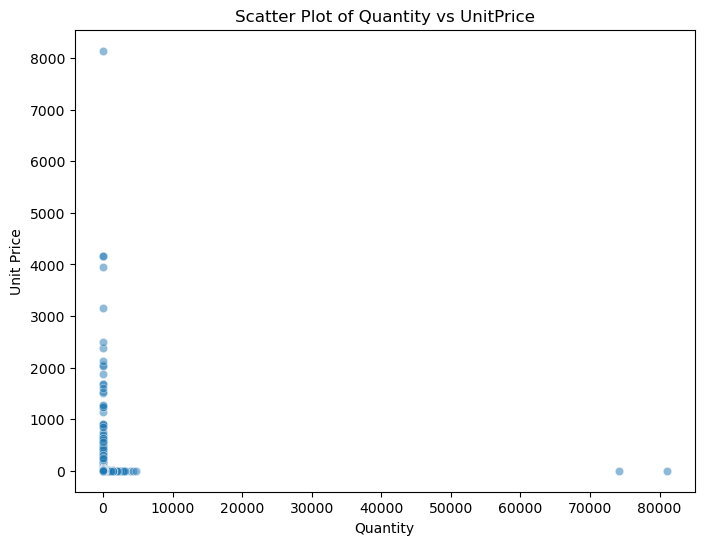

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Quantity', y='UnitPrice', alpha=0.5)
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.show()
